[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evinracher/3010192-advanced-simulation/blob/feat/assigment-4/assignments/assignment4-game-simulation.ipynb)

# Simulation and Empirical Probability in *Escaleras y Serpientes*

"""
This notebook studies a single-player version of the Colombian board game *Escaleras y Serpientes* by means of Monte Carlo simulation. The game is played on a board with squares numbered from 1 to 100. The player starts on square 1 and, on each turn, rolls a fair six-sided die. The token advances according to the outcome of the die. If the player lands exactly on the base of a ladder, the token immediately moves upward to the corresponding destination square. If the player lands on the head of a snake, the token immediately moves downward to the corresponding lower square. The game ends only when the player lands exactly on square 100. If a die roll would move the token beyond 100, the player remains in the same position and the turn is still counted.

The board used in this assignment contains the following ladders: 4→14, 9→31, 20→38, 28→84, 40→59, 63→81 and 71→91. It also contains the following snakes: 17→7, 54→34, 62→19, 64→60, 87→24, 93→73, 95→75 and 99→78. These special squares introduce upward and downward jumps that alter the duration and trajectory of the game.

For the simulation, the following assumptions are adopted: the die is fair, each roll is independent of the previous ones, there is only one player, the board configuration is fixed, the player always starts at square 1, and all ladder and snake transitions occur immediately after landing on the corresponding square. The computational objective is to approximate the probabilistic behavior of the game through repeated simulation, that is, through a Monte Carlo experiment.

Three random variables are defined for each simulated game. T denotes the total number of turns required to finish the game. E denotes the number of times the player lands on a ladder during the game. S denotes the number of times the player lands on a snake during the game. By simulating many independent games, it is possible to estimate the empirical distribution, expected value, variability and selected probabilities associated with these random variables.
"""

## Introduction

The purpose of this notebook is to explain the rules of the game, implement a reproducible simulation, and analyze the random variables associated with the gameplay. The presentation is organized so that the notebook can be executed from top to bottom and also used as support material for a 12-minute academic presentation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260413
rng = np.random.default_rng(SEED)

BOARD_START = 1
BOARD_END = 100

LADDERS = {
    4: 14,
    9: 31,
    20: 38,
    28: 84,
    40: 59,
    63: 81,
    71: 91,
}

SNAKES = {
    17: 7,
    54: 34,
    62: 19,
    64: 60,
    87: 24,
    93: 73,
    95: 75,
    99: 78,
}

pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print(f'Random seed fixed at {SEED}.')
print(f'Ladders: {LADDERS}')
print(f'Snakes: {SNAKES}')


Random seed fixed at 20260413.
Ladders: {4: 14, 9: 31, 20: 38, 28: 84, 40: 59, 63: 81, 71: 91}
Snakes: {17: 7, 54: 34, 62: 19, 64: 60, 87: 24, 93: 73, 95: 75, 99: 78}


## Game Definition

The simulation follows the assignment rules exactly:

- Single-player game.
- The player starts on square 1.
- Each turn consists of rolling a fair die with outcomes from 1 to 6.
- If the resulting move exceeds square 100, the player stays in place.
- If the player lands on a ladder, the token climbs immediately.
- If the player lands on a snake, the token descends immediately.
- The game finishes only when the player lands exactly on square 100.

The code is written in a modular way using two main functions:

- `simulate_one_game()` simulates one complete game and returns the random variables.
- `simulate_n_games(n)` repeats the experiment many times and stores the results in a `pandas` DataFrame.


In [2]:
def simulate_one_game(rng_instance=None, return_path=False, verbose=False):
    """Simulate one complete game of Snakes and Ladders.

    Parameters
    ----------
    rng_instance : numpy random generator, optional
        Random number generator to use. If None, the global generator is used.
    return_path : bool, optional
        If True, returns a list with step-by-step information.
    verbose : bool, optional
        If True, prints the progress of the game.

    Returns
    -------
    tuple
        (T, E, S) or (T, E, S, path).
    """
    if rng_instance is None:
        rng_instance = rng

    position = BOARD_START
    turns = 0
    ladders_count = 0
    snakes_count = 0
    path = []

    while position != BOARD_END:
        turns += 1
        roll = int(rng_instance.integers(1, 7))
        proposed_position = position + roll
        event = 'normal move'
        final_position = position

        if proposed_position > BOARD_END:
            event = 'exceeds 100, stays in place'
        else:
            final_position = proposed_position
            if final_position in LADDERS:
                ladders_count += 1
                final_position = LADDERS[final_position]
                event = 'ladder'
            elif final_position in SNAKES:
                snakes_count += 1
                final_position = SNAKES[final_position]
                event = 'snake'

        step_info = {
            'turn': turns,
            'start_position': position,
            'roll': roll,
            'proposed_position': proposed_position,
            'event': event,
            'final_position': final_position,
        }
        path.append(step_info)

        if verbose:
            print(
                f"Turn {turns:>2}: start={position:>3}, die={roll}, "
                f"proposed={proposed_position:>3}, event={event}, final={final_position:>3}"
            )

        position = final_position

    if return_path:
        return turns, ladders_count, snakes_count, path
    return turns, ladders_count, snakes_count


def simulate_n_games(n, rng_instance=None):
    """Simulate n independent games and return the results in a DataFrame."""
    if rng_instance is None:
        rng_instance = rng

    records = [simulate_one_game(rng_instance=rng_instance) for _ in range(n)]
    return pd.DataFrame(records, columns=['T', 'E', 'S'])


## Simulation

Before running the large Monte Carlo experiment, it is useful to observe one full game step by step. This section is appropriate for live explanation during the class presentation because it shows how die rolls, exact landing, ladders and snakes affect the evolution of the game.


In [3]:
demo_rng = np.random.default_rng(SEED)
demo_T, demo_E, demo_S, demo_path = simulate_one_game(
    rng_instance=demo_rng,
    return_path=True,
    verbose=True,
)

print('\nSummary of the demonstrated game:')
print(f'Total turns (T): {demo_T}')
print(f'Ladders used (E): {demo_E}')
print(f'Snakes encountered (S): {demo_S}')

demo_df = pd.DataFrame(demo_path)
demo_df.head(15)


Turn  1: start=  1, die=2, proposed=  3, event=normal move, final=  3
Turn  2: start=  3, die=4, proposed=  7, event=normal move, final=  7
Turn  3: start=  7, die=4, proposed= 11, event=normal move, final= 11
Turn  4: start= 11, die=3, proposed= 14, event=normal move, final= 14
Turn  5: start= 14, die=5, proposed= 19, event=normal move, final= 19
Turn  6: start= 19, die=4, proposed= 23, event=normal move, final= 23
Turn  7: start= 23, die=2, proposed= 25, event=normal move, final= 25
Turn  8: start= 25, die=6, proposed= 31, event=normal move, final= 31
Turn  9: start= 31, die=4, proposed= 35, event=normal move, final= 35
Turn 10: start= 35, die=2, proposed= 37, event=normal move, final= 37
Turn 11: start= 37, die=1, proposed= 38, event=normal move, final= 38
Turn 12: start= 38, die=2, proposed= 40, event=ladder, final= 59
Turn 13: start= 59, die=1, proposed= 60, event=normal move, final= 60
Turn 14: start= 60, die=2, proposed= 62, event=snake, final= 19
Turn 15: start= 19, die=2, prop

,turn,start_position,roll,proposed_position,event,final_position
0,1,1,2,3,normal move,3
1,2,3,4,7,normal move,7
2,3,7,4,11,normal move,11
3,4,11,3,14,normal move,14
4,5,14,5,19,normal move,19
5,6,19,4,23,normal move,23
6,7,23,2,25,normal move,25
7,8,25,6,31,normal move,31
8,9,31,4,35,normal move,35
9,10,35,2,37,normal move,37


## Results

Now the notebook performs a Monte Carlo simulation with many independent games. The resulting dataset stores one observation per game and one column per random variable:

- `T`: number of turns required to finish the game.
- `E`: number of ladder landings.
- `S`: number of snake landings.

Using a large number of simulations allows the empirical distribution to approximate the underlying probability distribution of the game.


In [4]:
n_games = 10_000
simulation_rng = np.random.default_rng(SEED)
results_df = simulate_n_games(n_games, rng_instance=simulation_rng)

print(f'Number of simulated games: {n_games}')
results_df.head()


Number of simulated games: 10000


,T,E,S
0,78,5,8
1,15,3,1
2,97,6,11
3,52,4,4
4,19,3,0


## Analysis

The next cells compute descriptive statistics and empirical probability distributions for the three random variables. Since the study is simulation-based, probabilities are estimated as relative frequencies.


In [5]:
def empirical_distribution(series):
    counts = series.value_counts().sort_index()
    probabilities = series.value_counts(normalize=True).sort_index()
    return pd.DataFrame({
        'frequency': counts,
        'probability': probabilities,
    })


def descriptive_statistics(series):
    mode_values = series.mode().tolist()
    return pd.Series({
        'mean': series.mean(),
        'variance': series.var(ddof=0),
        'std_dev': series.std(ddof=0),
        'median': series.median(),
        'mode': ', '.join(str(value) for value in mode_values),
        'min': series.min(),
        'max': series.max(),
        'range': series.max() - series.min(),
    })


T_distribution = empirical_distribution(results_df['T'])
E_distribution = empirical_distribution(results_df['E'])
S_distribution = empirical_distribution(results_df['S'])

summary_table = pd.DataFrame({
    'T': descriptive_statistics(results_df['T']),
    'E': descriptive_statistics(results_df['E']),
    'S': descriptive_statistics(results_df['S']),
})

common_T = T_distribution.sort_values('probability', ascending=False).head(5)

probability_examples = pd.Series({
    'P(T <= 20)': (results_df['T'] <= 20).mean(),
    'P(T <= 30)': (results_df['T'] <= 30).mean(),
    'P(T <= 40)': (results_df['T'] <= 40).mean(),
    'P(E = 0)': (results_df['E'] == 0).mean(),
    'P(E >= 1)': (results_df['E'] >= 1).mean(),
    'P(S = 0)': (results_df['S'] == 0).mean(),
    'P(S >= 1)': (results_df['S'] >= 1).mean(),
})

print('Descriptive statistics for T, E and S:')
display(summary_table)

print('Empirical distribution of T (first 15 values):')
display(T_distribution.head(15))

print('Empirical distribution of E:')
display(E_distribution)

print('Empirical distribution of S:')
display(S_distribution)

print('Most common exact values of T and their estimated probabilities:')
display(common_T)

print('Selected empirical probabilities:')
display(probability_examples.to_frame(name='probability'))


Descriptive statistics for T, E and S:


,T,E,S
mean,63.0159,3.5043,6.6403
variance,2188.4698,6.1372,41.6151
std_dev,46.7811,2.4773,6.4510
median,49.0000,3.0000,5.0000
mode,26,2,2
min,7,0,0
max,458,23,61
range,451,23,61


Empirical distribution of T (first 15 values):


,frequency,probability
T,,
7,3,0.0003
8,11,0.0011
9,21,0.0021
10,33,0.0033
11,43,0.0043
12,57,0.0057
13,54,0.0054
14,78,0.0078
15,78,0.0078


Empirical distribution of E:


...

,frequency,probability
S,,
0,785,0.0785
1,1040,0.1040
2,1094,0.1094
3,1003,0.1003
4,899,0.0899
...,...,...
50,1,0.0001
52,1,0.0001
53,1,0.0001


Most common exact values of T and their estimated probabilities:


,frequency,probability
T,,
26,173,0.0173
30,164,0.0164
24,163,0.0163
34,162,0.0162
33,160,0.0160


Selected empirical probabilities:


,probability
P(T <= 20),0.0942
P(T <= 30),0.2511
P(T <= 40),0.3983
P(E = 0),0.0193
P(E >= 1),0.9807
P(S = 0),0.0785
P(S >= 1),0.9215


The following figures summarize the distribution of the random variables. As requested, the notebook uses only `matplotlib`, one chart per figure, and default styling.


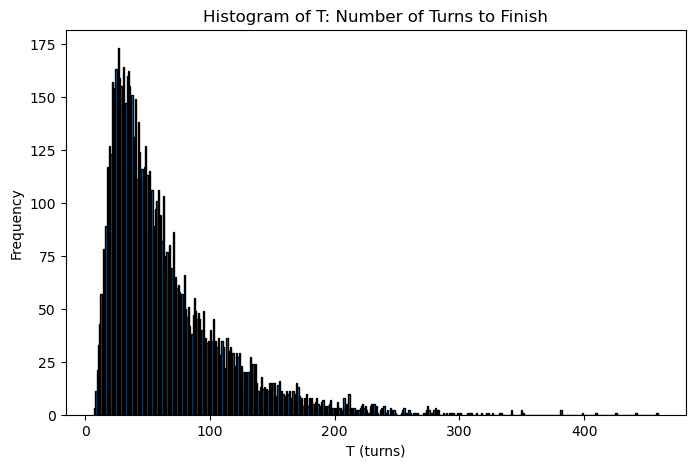

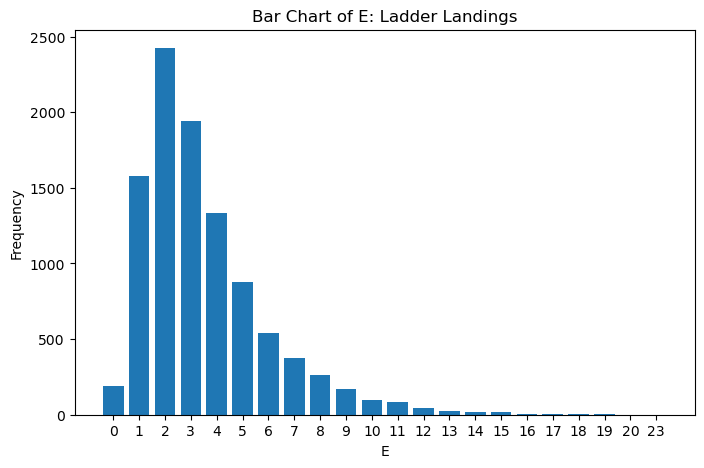

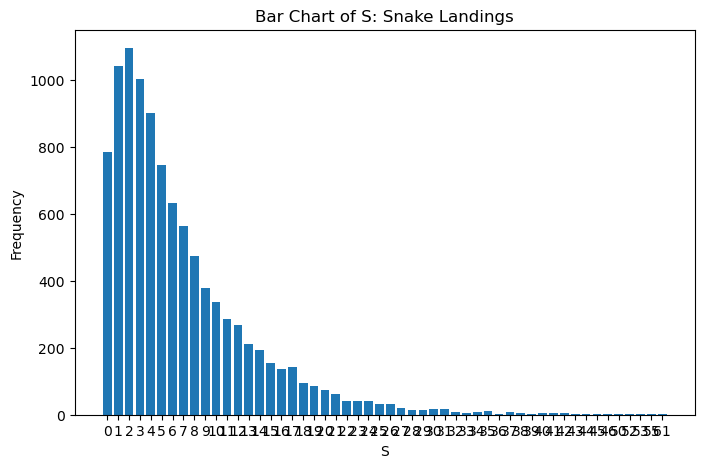

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(results_df['T'], bins=range(results_df['T'].min(), results_df['T'].max() + 2), edgecolor='black')
plt.title('Histogram of T: Number of Turns to Finish')
plt.xlabel('T (turns)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(E_distribution.index.astype(str), E_distribution['frequency'])
plt.title('Bar Chart of E: Ladder Landings')
plt.xlabel('E')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(S_distribution.index.astype(str), S_distribution['frequency'])
plt.title('Bar Chart of S: Snake Landings')
plt.xlabel('S')
plt.ylabel('Frequency')
plt.show()


## Conclusions

The simulation makes it possible to interpret the game from a probabilistic perspective:

- The average value of `T` represents the typical duration of the game in turns.
- The variance and standard deviation of `T` quantify how much the duration can fluctuate from one game to another.
- The variable `E` measures the beneficial effect of ladders, which reduce the distance to the goal and can shorten the game considerably.
- The variable `S` measures the negative effect of snakes, which send the player backwards and increase the possibility of long games.
- Comparing the empirical distributions of `E` and `S` helps explain why some games finish quickly while others take many more turns.

In summary, *Escaleras y Serpientes* is a clear example of a stochastic system in which random transitions generate observable distributions for relevant variables. Monte Carlo simulation provides an effective way to estimate those distributions and to connect theoretical probability with computational experimentation.


In [7]:
print('Interpretive summary based on the simulation:')
print(f"Average duration of the game: {results_df['T'].mean():.2f} turns.")
print(f"Standard deviation of T: {results_df['T'].std(ddof=0):.2f} turns.")
print(f"Average number of ladders per game: {results_df['E'].mean():.2f}.")
print(f"Average number of snakes per game: {results_df['S'].mean():.2f}.")
print(f"Probability of using at least one ladder: {(results_df['E'] >= 1).mean():.4f}.")
print(f"Probability of encountering at least one snake: {(results_df['S'] >= 1).mean():.4f}.")


Interpretive summary based on the simulation:
Average duration of the game: 63.02 turns.
Standard deviation of T: 46.78 turns.
Average number of ladders per game: 3.50.
Average number of snakes per game: 6.64.
Probability of using at least one ladder: 0.9807.
Probability of encountering at least one snake: 0.9215.
